C:\Users\shaun\AppData\Local\Temp\ipykernel_13560\3242914057.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].median(), inplace=True)
C:\Users\shaun\AppData\Local\Temp\ipykernel_13560\3242914057.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

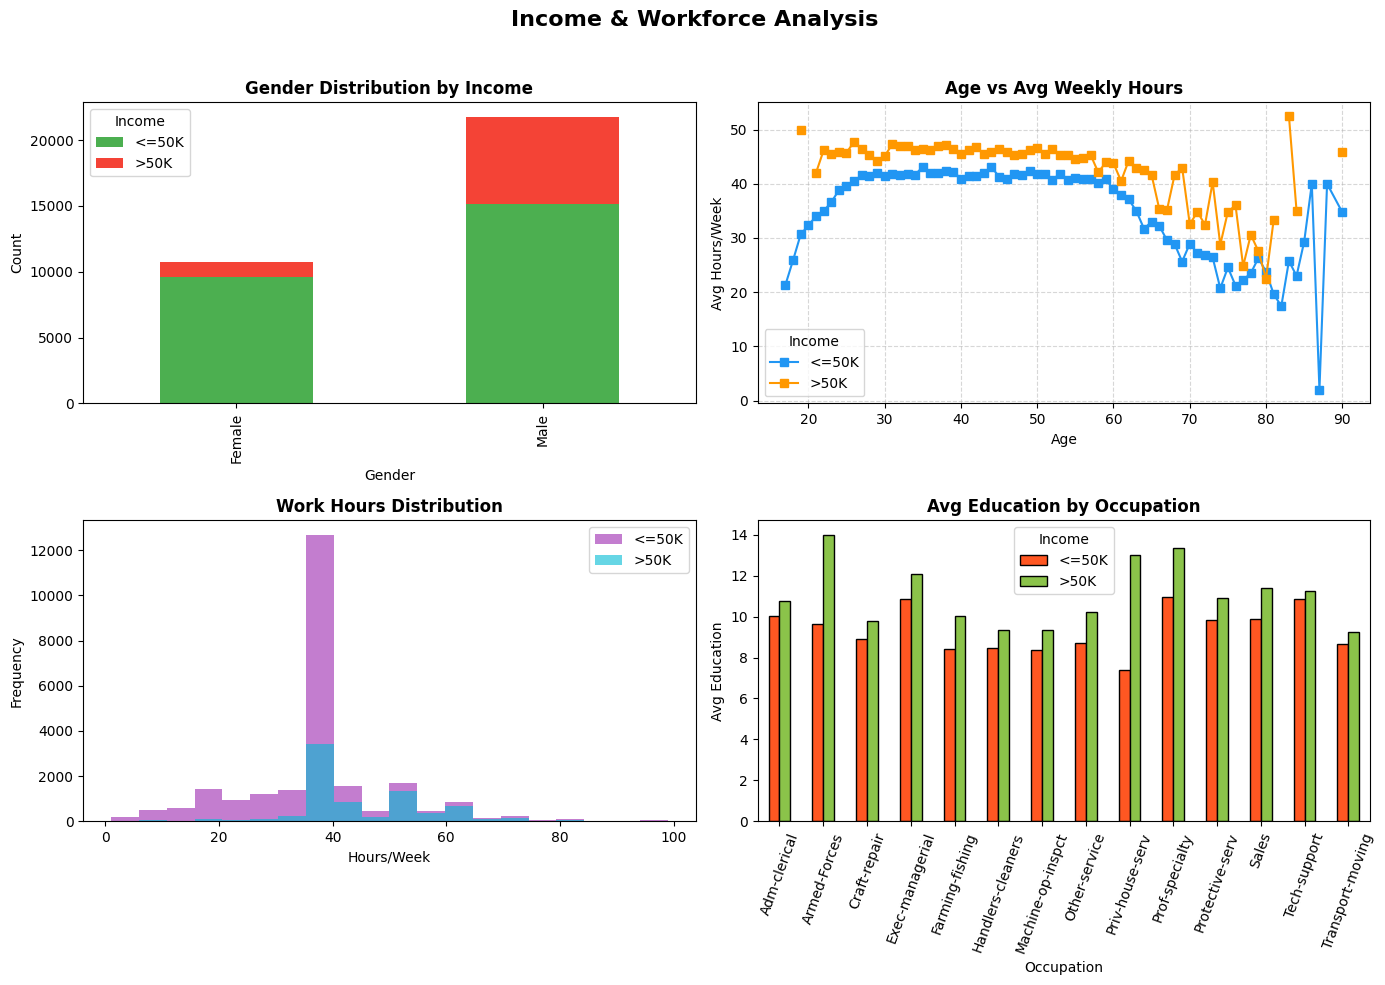

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def clean_df(df):
    df.replace('?', pd.NA, inplace=True)
    for c in df.columns:
        if df[c].dtype == 'object':
            df[c].fillna(df[c].mode()[0], inplace=True)
        else:
            df[c].fillna(df[c].median(), inplace=True)
    df.drop_duplicates(inplace=True)
    return df

def plot_gender_income(ax, df):
    df.groupby(['sex', 'income']).size().unstack().plot(
        kind='bar', stacked=True, ax=ax, color=['#4caf50','#f44336']  # green & red
    )
    ax.set_title('Gender Distribution by Income', fontsize=12, fontweight='bold')
    ax.set_xlabel('Gender')
    ax.set_ylabel('Count')
    ax.legend(title='Income')

def plot_age_hours(ax, df):
    df.groupby(['age', 'income'])['hours.per.week'].mean().unstack().plot(
        ax=ax, marker='s', linewidth=1.5, color=['#2196f3','#ff9800']  # blue & orange
    )
    ax.set_title('Age vs Avg Weekly Hours', fontsize=12, fontweight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('Avg Hours/Week')
    ax.legend(title='Income')
    ax.grid(True, linestyle='--', alpha=0.5)

def plot_hours_hist(ax, df):
    for inc, clr in zip(['<=50K','>50K'], ['#9c27b0','#00bcd4']):  # purple & cyan
        ax.hist(df[df['income']==inc]['hours.per.week'], bins=20, alpha=0.6, label=inc, color=clr)
    ax.set_title('Work Hours Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hours/Week')
    ax.set_ylabel('Frequency')
    ax.legend()

def plot_edu_occ(ax, df):
    df.groupby(['occupation','income'])['education.num'].mean().unstack().plot(
        kind='bar', ax=ax, color=['#ff5722','#8bc34a'], edgecolor='black' 
    )
    ax.set_title('Avg Education by Occupation', fontsize=12, fontweight='bold')
    ax.set_xlabel('Occupation')
    ax.set_ylabel('Avg Education')
    ax.legend(title='Income')
    ax.tick_params(axis='x', rotation=70)


df = clean_df(df)

fig, ax = plt.subplots(2,2, figsize=(14,10))
fig.suptitle('Income & Workforce Analysis', fontsize=16, fontweight='bold')

plot_gender_income(ax[0,0], df)
plot_age_hours(ax[0,1], df)
plot_hours_hist(ax[1,0], df)
plot_edu_occ(ax[1,1], df)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


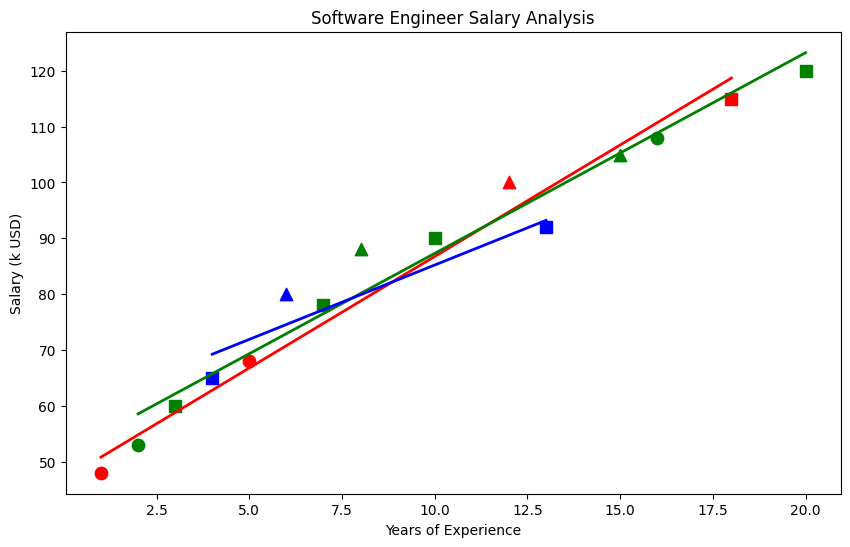

Coefficients: [ 4.71339249 -0.05847377  3.61521169 -1.17433308]
Intercept: 45.258449735194034
Predicted salaries: 86.55781855604307 105.84117620112697


In [8]:
import numpy as np
import matplotlib.pyplot as plt

exp = np.array([1,2,3,4,5,6,7,8,10,12,13,15,16,18,20])
edu = np.array([0,0,1,1,0,2,1,2,1,2,1,2,0,1,1])
loc = np.array([0,1,1,2,0,2,1,1,1,0,2,1,1,0,1])
sal = np.array([48,53,60,65,68,80,78,88,90,100,92,105,108,115,120])

colors = ['red', 'green', 'blue']
markers = ['o', 's', '^']

plt.figure(figsize=(10,6))
for l in range(3):
    for e in range(3):
        mask = (loc==l) & (edu==e)
        plt.scatter(exp[mask], sal[mask], color=colors[l], marker=markers[e], s=80)

for l in range(3):
    mask = loc==l
    x = exp[mask]
    y = sal[mask]
    coef = np.polyfit(x, y, 1)
    plt.plot(x, np.polyval(coef, x), color=colors[l], linewidth=2)

plt.xlabel('Years of Experience')
plt.ylabel('Salary (k USD)')
plt.title('Software Engineer Salary Analysis')
plt.show()

X = np.column_stack((exp, exp**2, edu, loc, np.ones(len(exp))))  # add intercept
beta = np.linalg.lstsq(X, sal, rcond=None)[0]
print("Coefficients:", beta[:-1])
print("Intercept:", beta[-1])

pred1 = np.dot([9, 81, 1, 0, 1], beta)
pred2 = np.dot([14, 196, 2, 1, 1], beta)
print("Predicted salaries:", pred1, pred2)
